# ESN Porto Events - Exploratory Data Analysis

**Objective**: Perform a comprehensive exploratory data analysis on ESN Porto's event data to uncover patterns, trends, and insights about their events organization and management.

**Dataset**: EventUpp Events Data from ESN Porto

## 1. Setup and Data Loading

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
from collections import Counter
import re

# Configuration
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 50)

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
# Load the data
with open('eventupp_events.json', 'r', encoding='utf-8') as f:
    events_data = json.load(f)

# Convert to DataFrame
df = pd.DataFrame(events_data)

print(f"Data loaded successfully!")
print(f"Total number of events: {len(df)}")

Data loaded successfully!
Total number of events: 1064


## 2. Initial Data Inspection

In [3]:
# Display basic information
print("Dataset Shape:", df.shape)
print("\n" + "="*80)
print("Column Names and Types:")
print(df.dtypes)

Dataset Shape: (1064, 32)

Column Names and Types:
_id                         object
name                        object
datetime                     int64
briefDescription            object
description                 object
location                    object
regularPrice               float64
organization                object
esnCardRequired               bool
createdBy                   object
active                        bool
shared                        bool
hostInvoicing                 bool
useRegularSeats               bool
options                     object
customEmailInfo             object
customPurchaseEmailInfo     object
wishlistEnabled               bool
allowExternalCards            bool
__v                          int64
imageURL                    object
seatsRemaining             float64
esnCardPrice               float64
datetimeLimit              float64
datetimeEnd                float64
seats                      float64
externalPayLink             object
esnC

In [4]:
# First few rows
df.head(10)

,_id,name,datetime,briefDescription,description,location,regularPrice,organization,esnCardRequired,createdBy,active,shared,hostInvoicing,useRegularSeats,options,customEmailInfo,customPurchaseEmailInfo,wishlistEnabled,allowExternalCards,__v,imageURL,seatsRemaining,esnCardPrice,datetimeLimit,datetimeEnd,seats,externalPayLink,esnCardBuyPrice,national,externalPayLabel,sharedSeats,nationalSeats
0,68d125ad00ab3a7cde88a032,10€ Beer Ticket,1796083200000,,<p>To track the purchases of the Beer Tickets....,office,10.0,5f1ebfbc2fd6333295e8e9af,False,Pedro Machado,True,False,False,False,[],<p><br></p>,<p><br></p>,False,False,0,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,68d125e700ab3a7cde88a091,5€ Beer Ticket,1793491200000,,<p>To track the purchases of the Beer Tickets....,office,5.0,5f1ebfbc2fd6333295e8e9af,False,Pedro Machado,True,False,False,False,[],<p><br></p>,<p><br></p>,False,False,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,68dea02b00ab3a7cde9d6199,Sports Day Insurance,1788562800000,,<p>The price is 5eur + online tax. 5eur cash i...,ESN,5.2,5f1ebfbc2fd6333295e8e9af,False,Afonso Faro,True,False,False,False,[],<p><br></p>,<p><br></p>,False,False,0,NaN,NaN,5.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,66d9ebba45281a95650c7e46,Photo Printing,1767139200000,Print one photo of you to add to your ESNcard,<p><br></p>,ESN Porto Office,1.0,5f1ebfbc2fd6333295e8e9af,False,Filipe Cerqueira,True,False,False,False,[],<p><br></p>,<p><br></p>,False,False,0,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,68d9c97a00ab3a7cde977b36,Lose Control Party,1760741820000,,<p>Lose Control Party @Hard Club</p>\r\n<h5>17...,Hard Club,8.0,5f1ebfbc2fd6333295e8e9af,True,Afonso Faro,True,False,False,False,[],<p><br></p>,<p><br></p>,False,False,0,None,NaN,NaN,1.760656e+12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,68d9c9a200ab3a7cde977b94,[GUEST] Lose Control Party,1760741820000,,<p>Lose Control Party @Hard Club</p>\r\n<h5>17...,Hard Club,12.0,5f1ebfbc2fd6333295e8e9af,False,Afonso Faro,True,False,False,False,[],<p><br></p>,<p><br></p>,False,False,0,NaN,NaN,NaN,1.760656e+12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,68d9c9d000ab3a7cde977bb0,[VOLUNTEERS] Lose Control Party,1760741820000,,<p>Lose Control Party @Hard Club</p>\r\n<h5>17...,Hard Club,0.0,5f1ebfbc2fd6333295e8e9af,False,Afonso Faro,True,False,False,False,[],<p><br></p>,<p><br></p>,False,False,0,NaN,NaN,NaN,1.760656e+12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,68d83b5000ab3a7cde95386b,Trip to Lisbon and Sintra,1760682600000,,<p>Nothing beats an ESN Porto trip!! And right...,Lisbon and Sintra,140.0,5f1ebfbc2fd6333295e8e9af,True,Afonso Faro,True,False,False,False,[],<p><br></p>,<p>Hi guys!!<br>\r\n<br>\r\nHere's some import...,False,False,0,None,39.0,NaN,1.760742e+12,1.760900e+12,55.0,NaN,NaN,NaN,NaN,NaN,NaN
8,68e0317d00ab3a7cde9f1e67,Mario Kart Tournament,1760022000000,,"<p>Start your engines, racers! 🏎️<br>\r\n<br>\...",ESN Porto Office,0.0,5f1ebfbc2fd6333295e8e9af,False,Office - ESN Porto,True,False,False,False,[],<p><br></p>,<p><br></p>,False,False,0,None,16.0,NaN,NaN,NaN,16.0,NaN,NaN,NaN,NaN,NaN,NaN
9,68dc121b00ab3a7cde9a641c,Boat Party,1759941000000,,<p><strong>ENGLISH:</strong></p>\r\n<p>Join us...,"Living Cruise, Vila Nova de Gaia",20.0,5f1ebfbc2fd6333295e8e9af,True,Office - ESN Porto,True,False,False,False,[],<p><br></p>,<p><br></p>,False,False,0,NaN,63.0,NaN,NaN,NaN,74.0,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# Last few rows
df.tail(10)

,_id,name,datetime,briefDescription,description,location,regularPrice,organization,esnCardRequired,createdBy,active,shared,hostInvoicing,useRegularSeats,options,customEmailInfo,customPurchaseEmailInfo,wishlistEnabled,allowExternalCards,__v,imageURL,seatsRemaining,esnCardPrice,datetimeLimit,datetimeEnd,seats,externalPayLink,esnCardBuyPrice,national,externalPayLabel,sharedSeats,nationalSeats
1054,613e7fa48c9cc82b158f00c8,Surf Course - 5 classes,1631527200000,,<p>Aloha!</p>\r\n<p>So you have been seeing so...,Flower Power Surf School,60.0,5f1ebfbc2fd6333295e8e9af,True,Office Team,False,False,False,False,[],<p><br></p>,<p><br></p>,False,False,0,None,112.0,0.0,NaN,1.643587e+12,150.0,NaN,NaN,NaN,NaN,NaN,NaN
1055,613e80608c9cc82b158f00c9,Surf Course - 8 Classes,1631487600000,,<p>Aloha!</p>\n<p>So you have been seeing some...,Flower Power Surf School,80.0,5f1ebfbc2fd6333295e8e9af,True,Office - ESN Porto,False,False,False,False,[],,,False,False,0,None,97.0,0.0,NaN,1.643587e+12,150.0,NaN,NaN,NaN,NaN,NaN,NaN
1056,60bf4002426ff0cdd835a1d3,Rainbow Farewell Sunset,1623780000000,,"<p><strong>Dear sunset lovers,</strong></p>\n<...",Rooftop Santa Catarina,5.0,5f1ebfbc2fd6333295e8e9af,True,Office - ESN Porto,False,False,False,False,[],,,False,False,0,None,-1.0,0.0,1.623776e+12,NaN,59.0,NaN,NaN,NaN,NaN,NaN,NaN
1057,60b7517c426ff0cdd835a105,Boat Trip & Wine Cellars,1623247200000,Hey there people! To participate in ESN ac...,,Ramos Pinto Cellars,5.0,5f1ebfbc2fd6333295e8e9af,True,Francisco Martins,False,False,False,False,[],,,False,False,0,None,1.0,5.0,NaN,NaN,45.0,NaN,NaN,NaN,NaN,NaN,NaN
1058,60a0ff22426ff0cdd8359d9c,Cultural Day @CasaDaMúsica 15:00,1622037600000,,<p>Porto is a very cultural city and we are he...,Casa da Música,3.5,5f1ebfbc2fd6333295e8e9af,True,Office - ESN Porto,False,False,False,False,[],,,False,False,0,None,9.0,0.0,NaN,NaN,9.0,NaN,NaN,NaN,NaN,NaN,NaN
1059,60a0ff34426ff0cdd8359d9d,Cultural Day @CasaDaMúsica 16:00,1622037600000,,<p>Porto is a very cultural city and we are he...,Casa da Música,3.5,5f1ebfbc2fd6333295e8e9af,True,Office - ESN Porto,False,False,False,False,[],,,False,False,0,None,1.0,0.0,NaN,NaN,9.0,NaN,NaN,NaN,NaN,NaN,NaN
1060,609fbb6c426ff0cdd8359d76,Bike Tour,1621958400000,,<p>Bike Tour 11th of May of 2021 To participat...,Velurb,6.0,5f1ebfbc2fd6333295e8e9af,True,Office - ESN Porto,False,False,False,False,[],,,False,False,0,None,7.0,0.0,NaN,NaN,15.0,NaN,NaN,NaN,NaN,NaN,NaN
1061,609fbbfe426ff0cdd8359d77,Clérigos by Sunset,1621441800000,,"<p>Hey everyone,</p>\n<p>Sunsets are one of th...",Clérigos,4.0,5f1ebfbc2fd6333295e8e9af,True,Office - ESN Porto,False,False,False,False,[],,,False,False,0,None,4.0,0.0,NaN,NaN,20.0,NaN,NaN,NaN,NaN,NaN,NaN
1062,60743ac05e98dbef772726e7,Cultural Day at Sé do Porto,1619622000000,,<p>Hello explorers!</p>\n<p>Porto is a very cu...,Sé do Porto,3.0,5f1ebfbc2fd6333295e8e9af,True,Office - ESN Porto,False,False,False,False,[],<p><br></p>,,False,False,0,None,8.0,3.0,NaN,NaN,20.0,NaN,NaN,NaN,NaN,NaN,NaN
1063,5f808e9dc6e6f62ef644ba2a,COVID-LIST,1602260596584,,,Porto,0.0,5f1ebfbc2fd6333295e8e9af,True,Office Team,False,False,False,False,[],,,False,False,0,None,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# Check for missing values
missing_data = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum().values,
    'Missing_Percentage': (df.isnull().sum().values / len(df) * 100).round(2)
}).sort_values('Missing_Count', ascending=False)

print("Missing Values Analysis:")
print(missing_data[missing_data['Missing_Count'] > 0])

Missing Values Analysis:
              Column  Missing_Count  Missing_Percentage
29  externalPayLabel           1064              100.00
26   externalPayLink           1063               99.91
31     nationalSeats           1063               99.91
30       sharedSeats           1062               99.81
20          imageURL           1060               99.62
27   esnCardBuyPrice           1058               99.44
24       datetimeEnd            843               79.23
22      esnCardPrice            807               75.85
28          national            755               70.96
23     datetimeLimit            391               36.75
25             seats             73                6.86
21    seatsRemaining             72                6.77


In [7]:
# Data info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1064 entries, 0 to 1063
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   _id                      1064 non-null   object 
 1   name                     1064 non-null   object 
 2   datetime                 1064 non-null   int64  
 3   briefDescription         1064 non-null   object 
 4   description              1064 non-null   object 
 5   location                 1064 non-null   object 
 6   regularPrice             1064 non-null   float64
 7   organization             1064 non-null   object 
 8   esnCardRequired          1064 non-null   bool   
 9   createdBy                1064 non-null   object 
 10  active                   1064 non-null   bool   
 11  shared                   1064 non-null   bool   
 12  hostInvoicing            1064 non-null   bool   
 13  useRegularSeats          1064 non-null   bool   
 14  options                 

## 3. Data Cleaning and Preprocessing

In [8]:
# Create a copy for cleaning
df_clean = df.copy()

# Convert datetime from milliseconds to datetime objects
df_clean['datetime'] = pd.to_datetime(df_clean['datetime'], unit='ms')

# Extract temporal features
df_clean['year'] = df_clean['datetime'].dt.year
df_clean['month'] = df_clean['datetime'].dt.month
df_clean['month_name'] = df_clean['datetime'].dt.month_name()
df_clean['day_of_week'] = df_clean['datetime'].dt.day_name()
df_clean['hour'] = df_clean['datetime'].dt.hour
df_clean['day'] = df_clean['datetime'].dt.day
df_clean['quarter'] = df_clean['datetime'].dt.quarter

# Create date-only column
df_clean['date'] = df_clean['datetime'].dt.date

# Clean text fields - remove HTML tags
def remove_html_tags(text):
    if pd.isna(text) or text == '':
        return ''
    clean = re.compile('<.*?>')
    return re.sub(clean, '', str(text)).strip()

df_clean['description_clean'] = df_clean['description'].apply(remove_html_tags)
df_clean['briefDescription_clean'] = df_clean['briefDescription'].apply(remove_html_tags)

# Add price difference (if ESN card price exists)
df_clean['price_discount'] = df_clean.apply(
    lambda row: row['regularPrice'] - row['esnCardPrice'] 
    if pd.notna(row.get('esnCardPrice')) else 0, axis=1
)

df_clean['has_esn_discount'] = df_clean['price_discount'] > 0

print("Data cleaning completed!")
print(f"Date range: {df_clean['datetime'].min()} to {df_clean['datetime'].max()}")

Data cleaning completed!
Date range: 2020-10-09 16:23:16.584000 to 2026-12-01 00:00:00


## 4. Statistical Summary

In [9]:
# Numerical columns summary
numerical_cols = ['regularPrice', 'esnCardPrice', 'price_discount']
df_clean[numerical_cols].describe()

,regularPrice,esnCardPrice,price_discount
count,1064.000000,257.000000,1064.000000
mean,11.588806,6.076304,1.946983
std,23.856478,19.643592,10.254264
min,0.000000,-0.040000,-10.000000
25%,0.000000,0.000000,0.000000
50%,5.000000,0.000000,0.000000
75%,12.000000,3.000000,0.000000
max,175.000000,140.000000,130.000000


In [10]:
# Categorical summary
categorical_summary = pd.DataFrame({
    'Total Events': [len(df_clean)],
    'Active Events': [df_clean['active'].sum()],
    'Inactive Events': [(~df_clean['active']).sum()],
    'ESN Card Required': [df_clean['esnCardRequired'].sum()],
    'Shared Events': [df_clean['shared'].sum()],
    'Wishlist Enabled': [df_clean['wishlistEnabled'].sum()],
    'External Cards Allowed': [df_clean['allowExternalCards'].sum()],
    'Events with ESN Discount': [df_clean['has_esn_discount'].sum()],
}).T

categorical_summary.columns = ['Count']
categorical_summary['Percentage'] = (categorical_summary['Count'] / len(df_clean) * 100).round(2)
categorical_summary

,Count,Percentage
Total Events,1064,100.00
Active Events,1029,96.71
Inactive Events,35,3.29
ESN Card Required,857,80.55
Shared Events,3,0.28
Wishlist Enabled,1,0.09
External Cards Allowed,17,1.60
Events with ESN Discount,108,10.15


In [11]:
# Unique values in key columns
print("Unique Values:")
print(f"Unique Locations: {df_clean['location'].nunique()}")
print(f"Unique Creators: {df_clean['createdBy'].nunique()}")
print(f"Unique Years: {df_clean['year'].nunique()}")
print(f"Unique Months: {df_clean['month'].nunique()}")

Unique Values:
Unique Locations: 335
Unique Creators: 48
Unique Years: 7
Unique Months: 10


## 5. Temporal Analysis

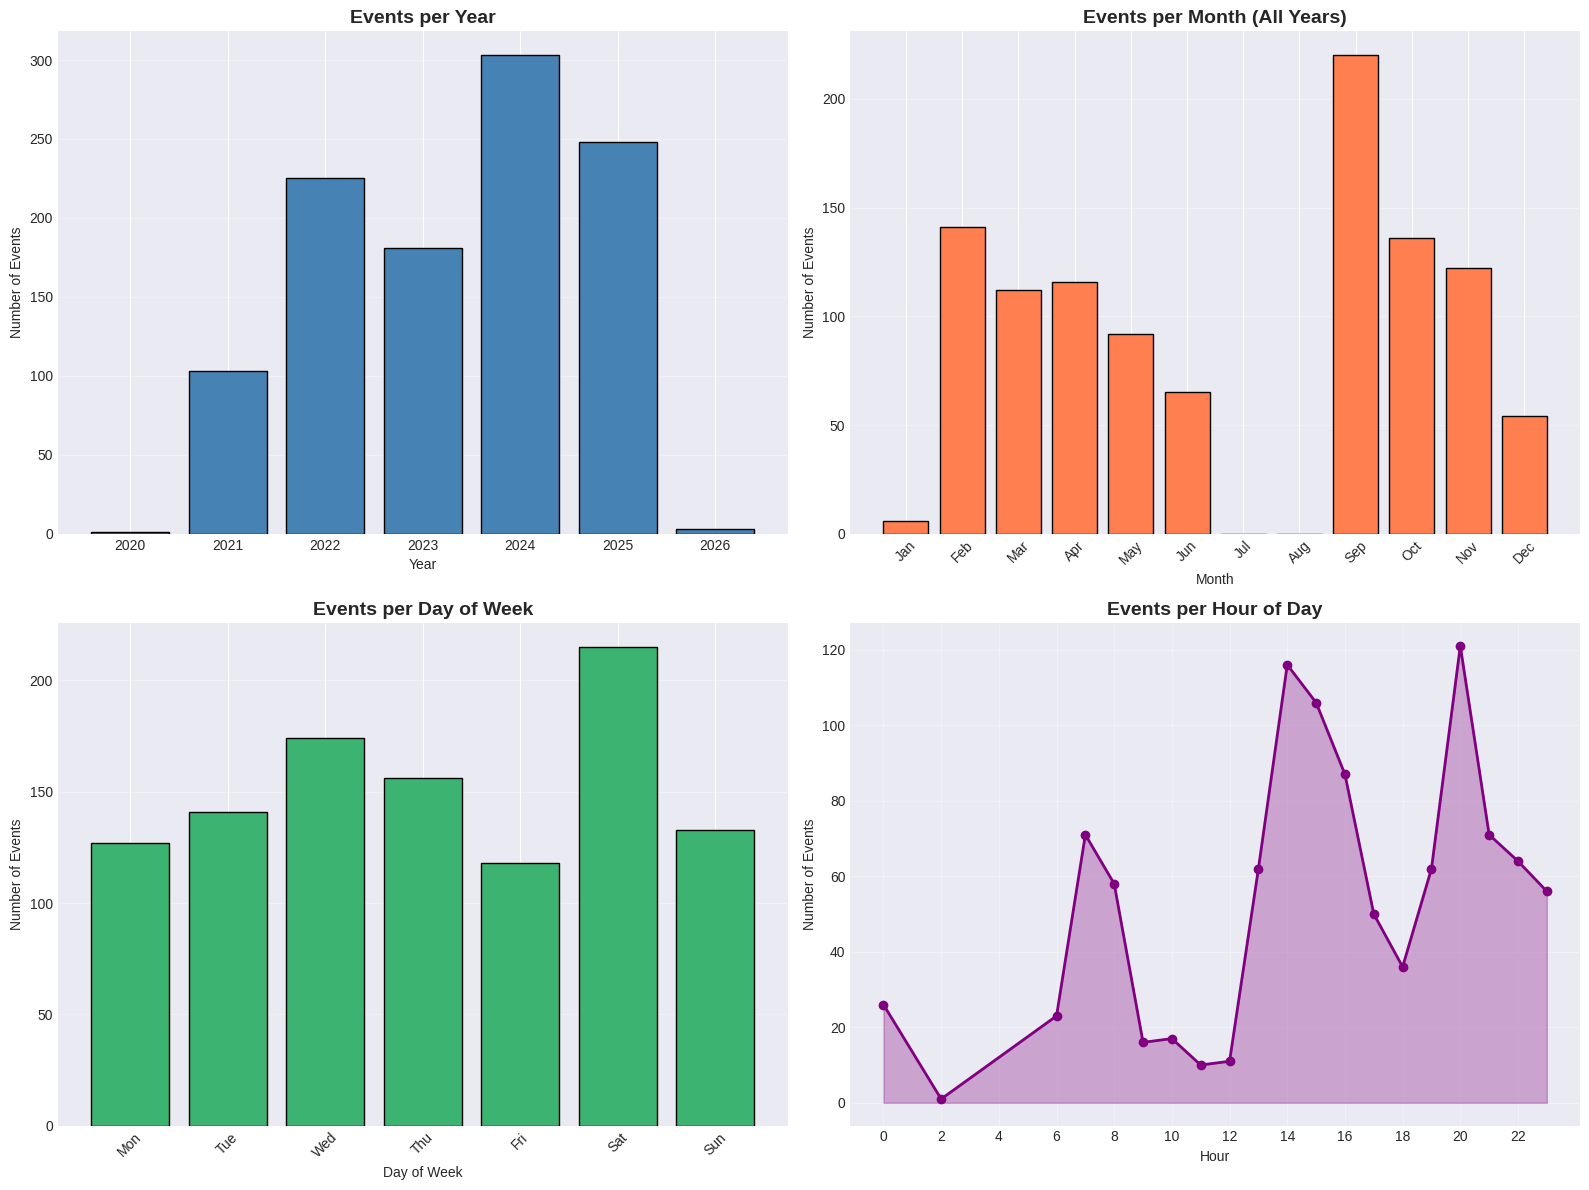

In [12]:
# Events over time
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Events per year
events_per_year = df_clean['year'].value_counts().sort_index()
axes[0, 0].bar(events_per_year.index, events_per_year.values, color='steelblue', edgecolor='black')
axes[0, 0].set_title('Events per Year', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Year')
axes[0, 0].set_ylabel('Number of Events')
axes[0, 0].grid(axis='y', alpha=0.3)

# Events per month
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
events_per_month = df_clean['month_name'].value_counts().reindex(month_order, fill_value=0)
axes[0, 1].bar(range(len(events_per_month)), events_per_month.values, 
               color='coral', edgecolor='black')
axes[0, 1].set_title('Events per Month (All Years)', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Month')
axes[0, 1].set_ylabel('Number of Events')
axes[0, 1].set_xticks(range(12))
axes[0, 1].set_xticklabels([m[:3] for m in month_order], rotation=45)
axes[0, 1].grid(axis='y', alpha=0.3)

# Events per day of week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
events_per_day = df_clean['day_of_week'].value_counts().reindex(day_order, fill_value=0)
axes[1, 0].bar(range(len(events_per_day)), events_per_day.values, 
               color='mediumseagreen', edgecolor='black')
axes[1, 0].set_title('Events per Day of Week', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Day of Week')
axes[1, 0].set_ylabel('Number of Events')
axes[1, 0].set_xticks(range(7))
axes[1, 0].set_xticklabels([d[:3] for d in day_order], rotation=45)
axes[1, 0].grid(axis='y', alpha=0.3)

# Events per hour
events_per_hour = df_clean['hour'].value_counts().sort_index()
axes[1, 1].plot(events_per_hour.index, events_per_hour.values, 
                marker='o', linewidth=2, markersize=6, color='purple')
axes[1, 1].fill_between(events_per_hour.index, events_per_hour.values, alpha=0.3, color='purple')
axes[1, 1].set_title('Events per Hour of Day', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Hour')
axes[1, 1].set_ylabel('Number of Events')
axes[1, 1].set_xticks(range(0, 24, 2))
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

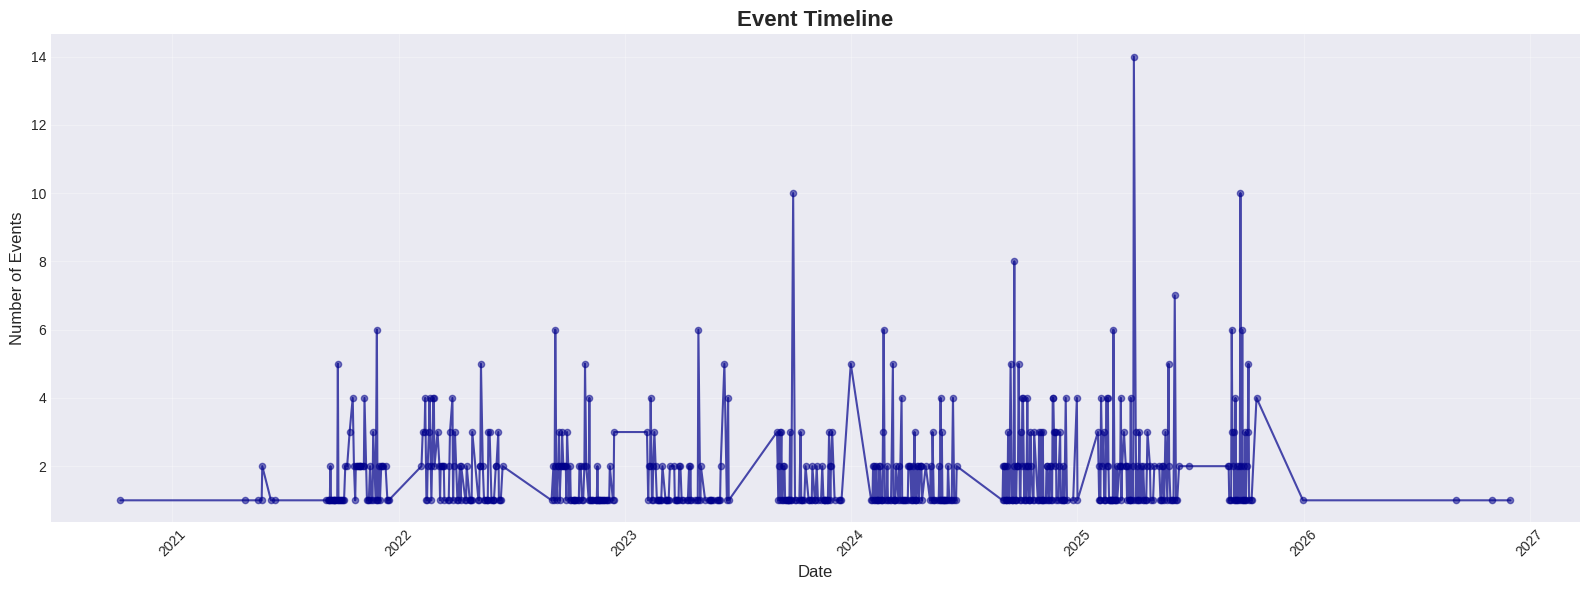

In [13]:
# Timeline of events
fig, ax = plt.subplots(figsize=(16, 6))

events_by_date = df_clean.groupby('date').size().reset_index(name='count')
events_by_date['date'] = pd.to_datetime(events_by_date['date'])
events_by_date = events_by_date.sort_values('date')

ax.plot(events_by_date['date'], events_by_date['count'], 
        linewidth=1.5, alpha=0.7, color='darkblue')
ax.scatter(events_by_date['date'], events_by_date['count'], 
           s=20, alpha=0.5, color='darkblue')

ax.set_title('Event Timeline', fontsize=16, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Number of Events', fontsize=12)
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

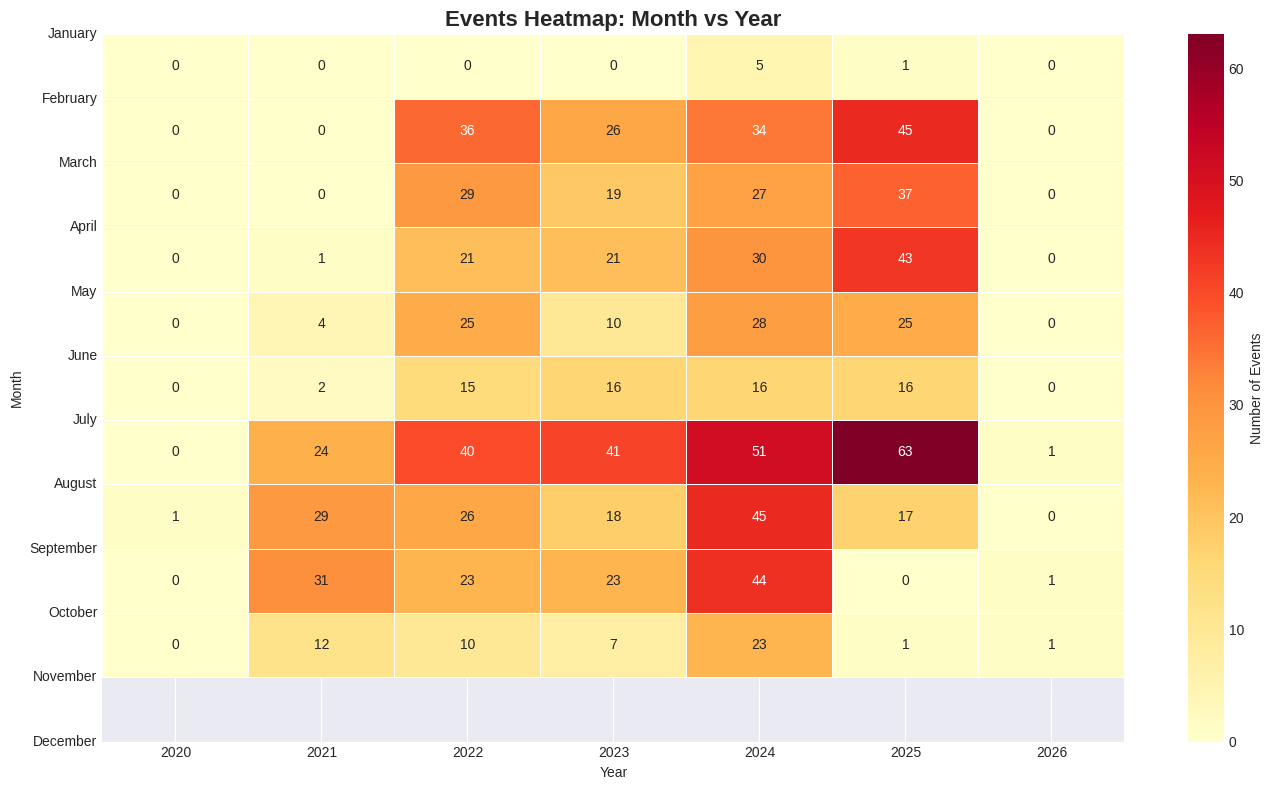

In [14]:
# Heatmap: Events by month and year
events_month_year = df_clean.groupby(['year', 'month']).size().reset_index(name='count')
pivot_table = events_month_year.pivot(index='month', columns='year', values='count').fillna(0)

plt.figure(figsize=(14, 8))
sns.heatmap(pivot_table, annot=True, fmt='.0f', cmap='YlOrRd', 
            linewidths=0.5, cbar_kws={'label': 'Number of Events'})
plt.title('Events Heatmap: Month vs Year', fontsize=16, fontweight='bold')
plt.ylabel('Month')
plt.xlabel('Year')
plt.yticks(ticks=range(12), labels=month_order, rotation=0)
plt.tight_layout()
plt.show()

## 6. Price Analysis

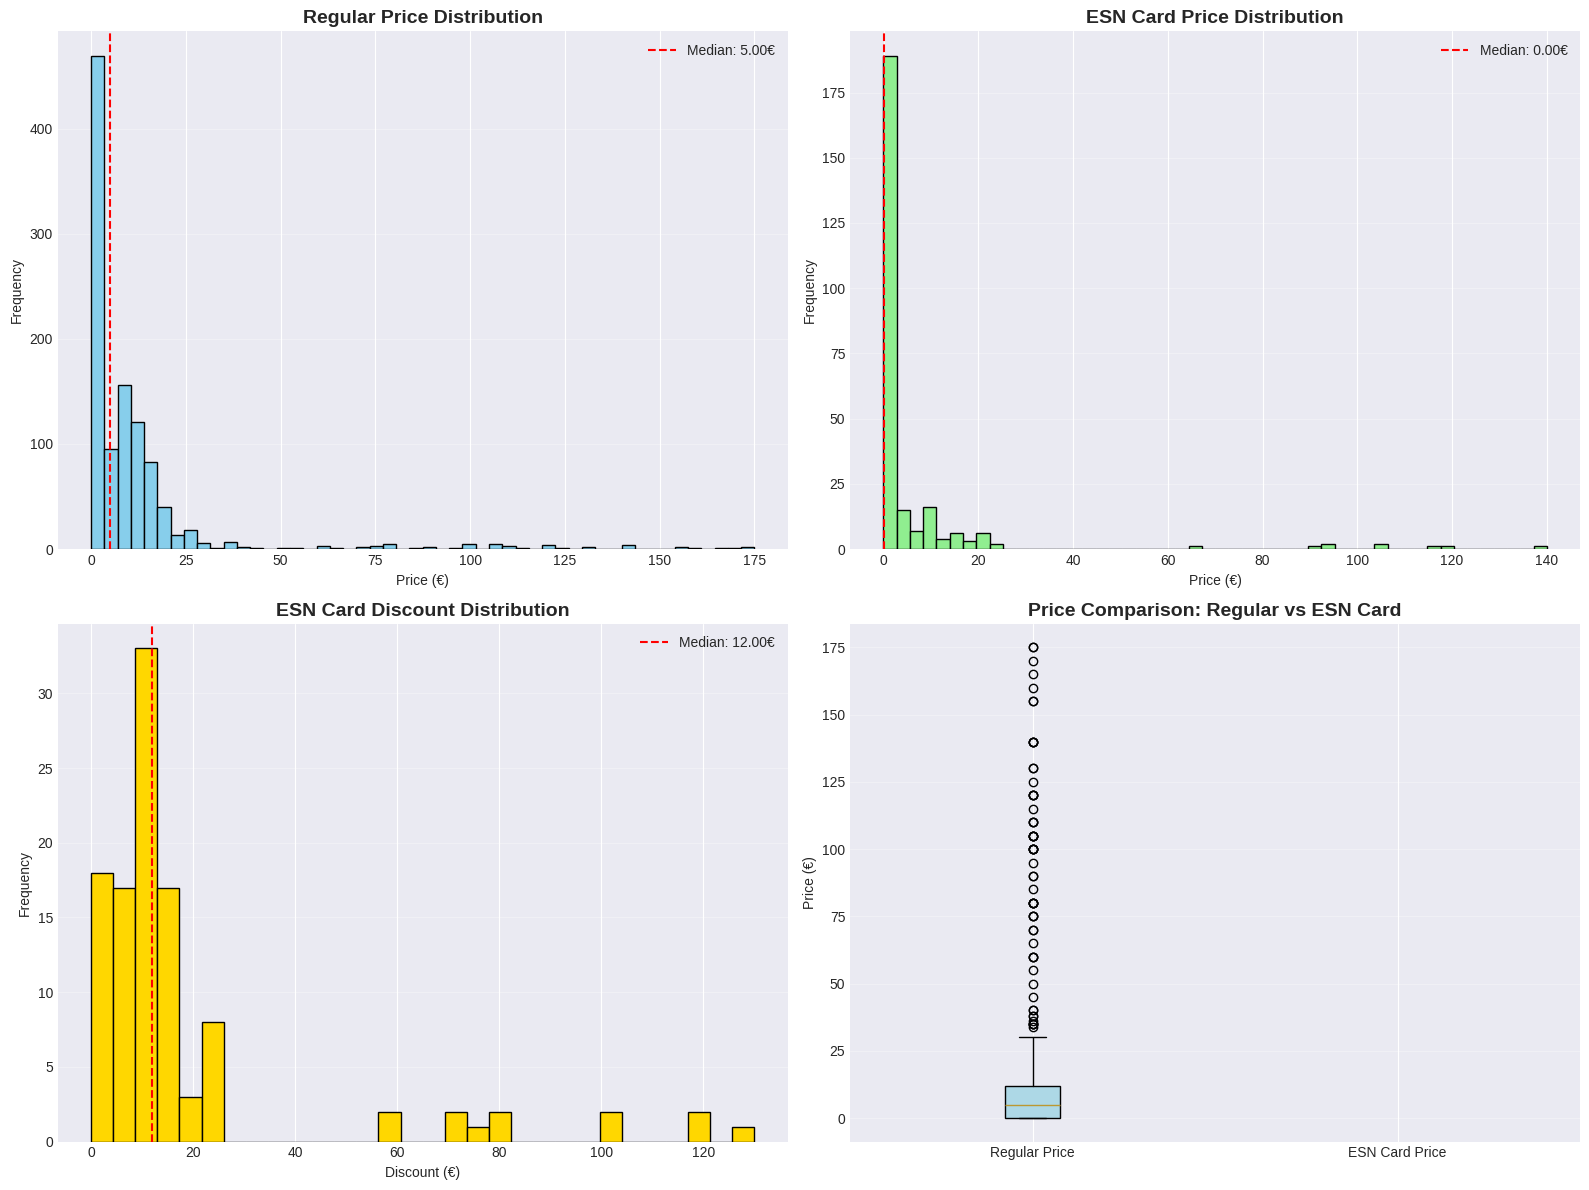

In [15]:
# Price distribution
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Regular price distribution
axes[0, 0].hist(df_clean['regularPrice'].dropna(), bins=50, edgecolor='black', color='skyblue')
axes[0, 0].set_title('Regular Price Distribution', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Price (€)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].axvline(df_clean['regularPrice'].median(), color='red', 
                   linestyle='--', label=f'Median: {df_clean["regularPrice"].median():.2f}€')
axes[0, 0].legend()
axes[0, 0].grid(axis='y', alpha=0.3)

# ESN Card price distribution
esn_prices = df_clean['esnCardPrice'].dropna()
if len(esn_prices) > 0:
    axes[0, 1].hist(esn_prices, bins=50, edgecolor='black', color='lightgreen')
    axes[0, 1].set_title('ESN Card Price Distribution', fontsize=14, fontweight='bold')
    axes[0, 1].set_xlabel('Price (€)')
    axes[0, 1].set_ylabel('Frequency')
    axes[0, 1].axvline(esn_prices.median(), color='red', 
                       linestyle='--', label=f'Median: {esn_prices.median():.2f}€')
    axes[0, 1].legend()
    axes[0, 1].grid(axis='y', alpha=0.3)

# Price discount distribution
discounts = df_clean[df_clean['has_esn_discount']]['price_discount']
if len(discounts) > 0:
    axes[1, 0].hist(discounts, bins=30, edgecolor='black', color='gold')
    axes[1, 0].set_title('ESN Card Discount Distribution', fontsize=14, fontweight='bold')
    axes[1, 0].set_xlabel('Discount (€)')
    axes[1, 0].set_ylabel('Frequency')
    axes[1, 0].axvline(discounts.median(), color='red', 
                       linestyle='--', label=f'Median: {discounts.median():.2f}€')
    axes[1, 0].legend()
    axes[1, 0].grid(axis='y', alpha=0.3)

# Box plot comparison
price_comparison = pd.DataFrame({
    'Regular Price': df_clean['regularPrice'].dropna(),
    'ESN Card Price': df_clean['esnCardPrice'].dropna()
})
axes[1, 1].boxplot([price_comparison['Regular Price'], price_comparison['ESN Card Price']], 
                    labels=['Regular Price', 'ESN Card Price'],
                    patch_artist=True,
                    boxprops=dict(facecolor='lightblue'))
axes[1, 1].set_title('Price Comparison: Regular vs ESN Card', fontsize=14, fontweight='bold')
axes[1, 1].set_ylabel('Price (€)')
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [16]:
# Price statistics by year
price_by_year = df_clean.groupby('year')['regularPrice'].agg(['mean', 'median', 'min', 'max', 'count'])
price_by_year.columns = ['Average', 'Median', 'Min', 'Max', 'Event Count']
price_by_year = price_by_year.round(2)
price_by_year

,Average,Median,Min,Max,Event Count
year,,,,,
2020,0.00,0.00,0.0,0.0,1
2021,11.40,6.00,0.0,130.0,103
2022,17.80,10.00,0.0,140.0,225
2023,14.26,8.00,0.0,175.0,181
2024,8.26,5.00,0.0,170.0,303
2025,8.26,2.75,0.0,165.0,248
2026,6.73,5.20,5.0,10.0,3


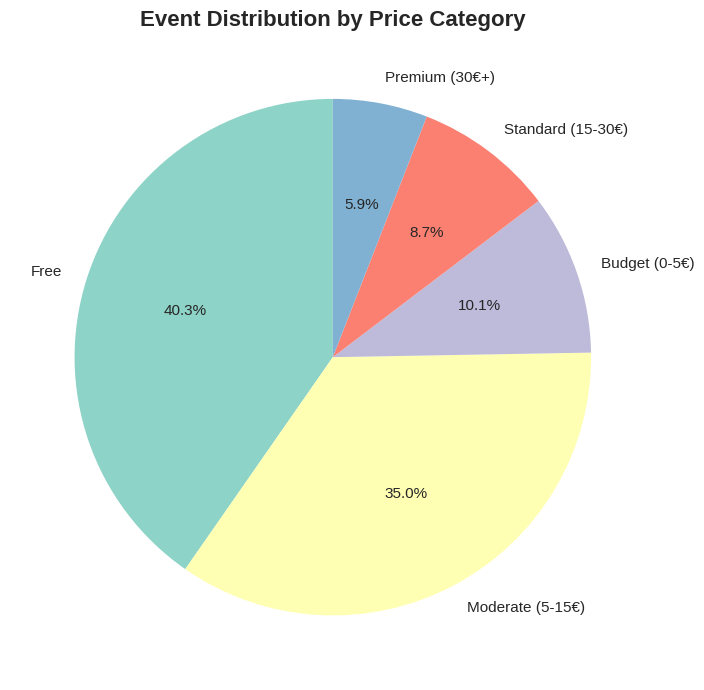


Event Count by Price Category:
price_category
Free                 429
Moderate (5-15€)     372
Budget (0-5€)        107
Standard (15-30€)     93
Premium (30€+)        63
Name: count, dtype: int64


In [17]:
# Price categories
def categorize_price(price):
    if pd.isna(price):
        return 'Unknown'
    elif price == 0:
        return 'Free'
    elif price <= 5:
        return 'Budget (0-5€)'
    elif price <= 15:
        return 'Moderate (5-15€)'
    elif price <= 30:
        return 'Standard (15-30€)'
    else:
        return 'Premium (30€+)'

df_clean['price_category'] = df_clean['regularPrice'].apply(categorize_price)

# Plot price categories
fig, ax = plt.subplots(figsize=(12, 7))
price_cat_counts = df_clean['price_category'].value_counts()
colors = plt.cm.Set3(range(len(price_cat_counts)))
wedges, texts, autotexts = ax.pie(price_cat_counts.values, 
                                    labels=price_cat_counts.index,
                                    autopct='%1.1f%%',
                                    startangle=90,
                                    colors=colors,
                                    textprops={'fontsize': 11})
ax.set_title('Event Distribution by Price Category', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nEvent Count by Price Category:")
print(price_cat_counts)

## 7. Location Analysis

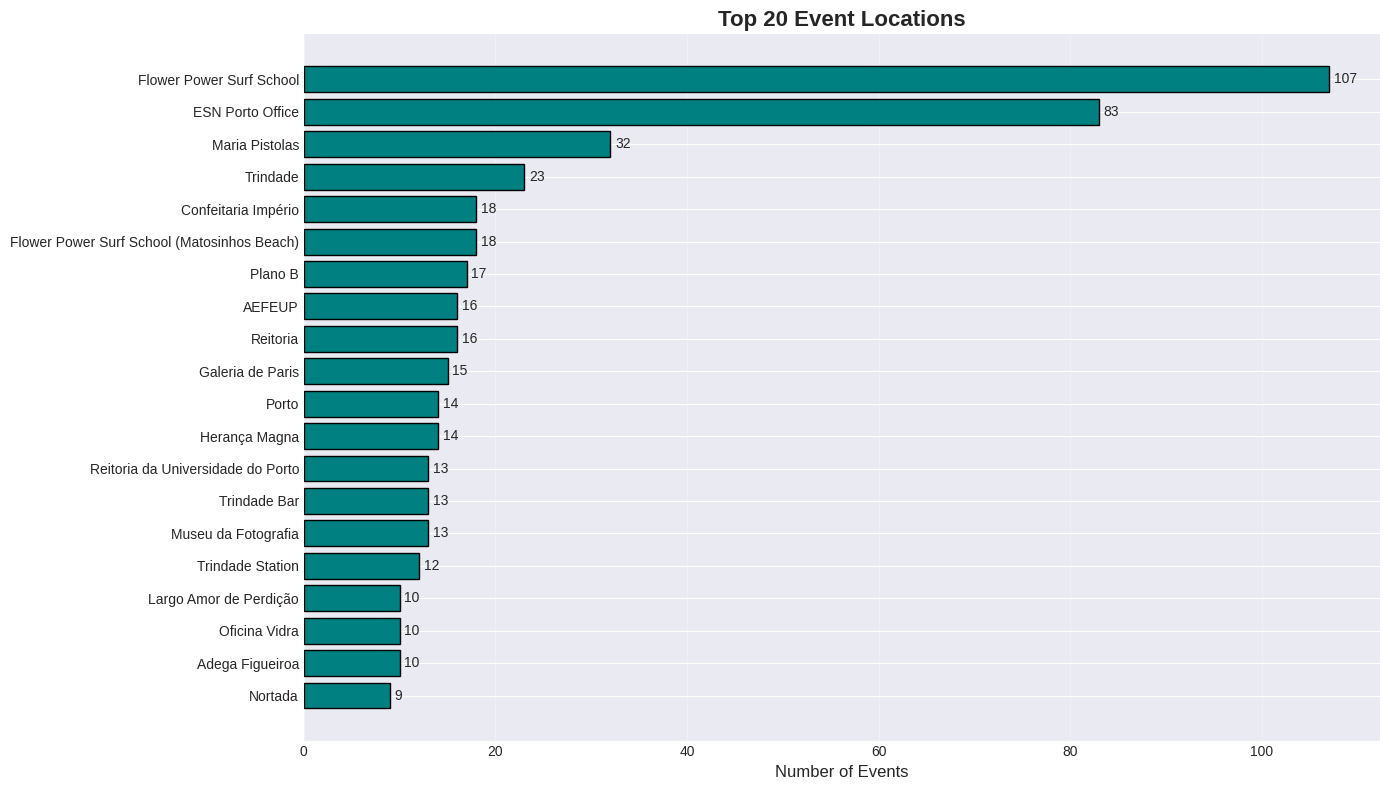


Total unique locations: 335


In [18]:
# Top locations
top_locations = df_clean['location'].value_counts().head(20)

fig, ax = plt.subplots(figsize=(14, 8))
bars = ax.barh(range(len(top_locations)), top_locations.values, color='teal', edgecolor='black')
ax.set_yticks(range(len(top_locations)))
ax.set_yticklabels(top_locations.index)
ax.set_xlabel('Number of Events', fontsize=12)
ax.set_title('Top 20 Event Locations', fontsize=16, fontweight='bold')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)

# Add value labels
for i, v in enumerate(top_locations.values):
    ax.text(v + 0.5, i, str(v), va='center')

plt.tight_layout()
plt.show()

print(f"\nTotal unique locations: {df_clean['location'].nunique()}")

In [19]:
# Average price by top locations
location_price = df_clean.groupby('location').agg({
    'regularPrice': ['mean', 'median', 'count']
}).round(2)
location_price.columns = ['Avg Price', 'Median Price', 'Event Count']
location_price = location_price[location_price['Event Count'] >= 5].sort_values('Event Count', ascending=False)

print("Average Prices by Location (min 5 events):")
location_price.head(15)

Average Prices by Location (min 5 events):


,Avg Price,Median Price,Event Count
location,,,
Flower Power Surf School,10.62,10.0,107
ESN Porto Office,3.01,0.0,83
Maria Pistolas,1.19,0.0,32
Trindade,57.70,35.0,23
Confeitaria Império,12.11,12.0,18
Flower Power Surf School (Matosinhos Beach),10.33,10.0,18
Plano B,0.00,0.0,17
Reitoria,25.25,20.0,16
AEFEUP,3.62,4.0,16


## 8. Event Creator Analysis

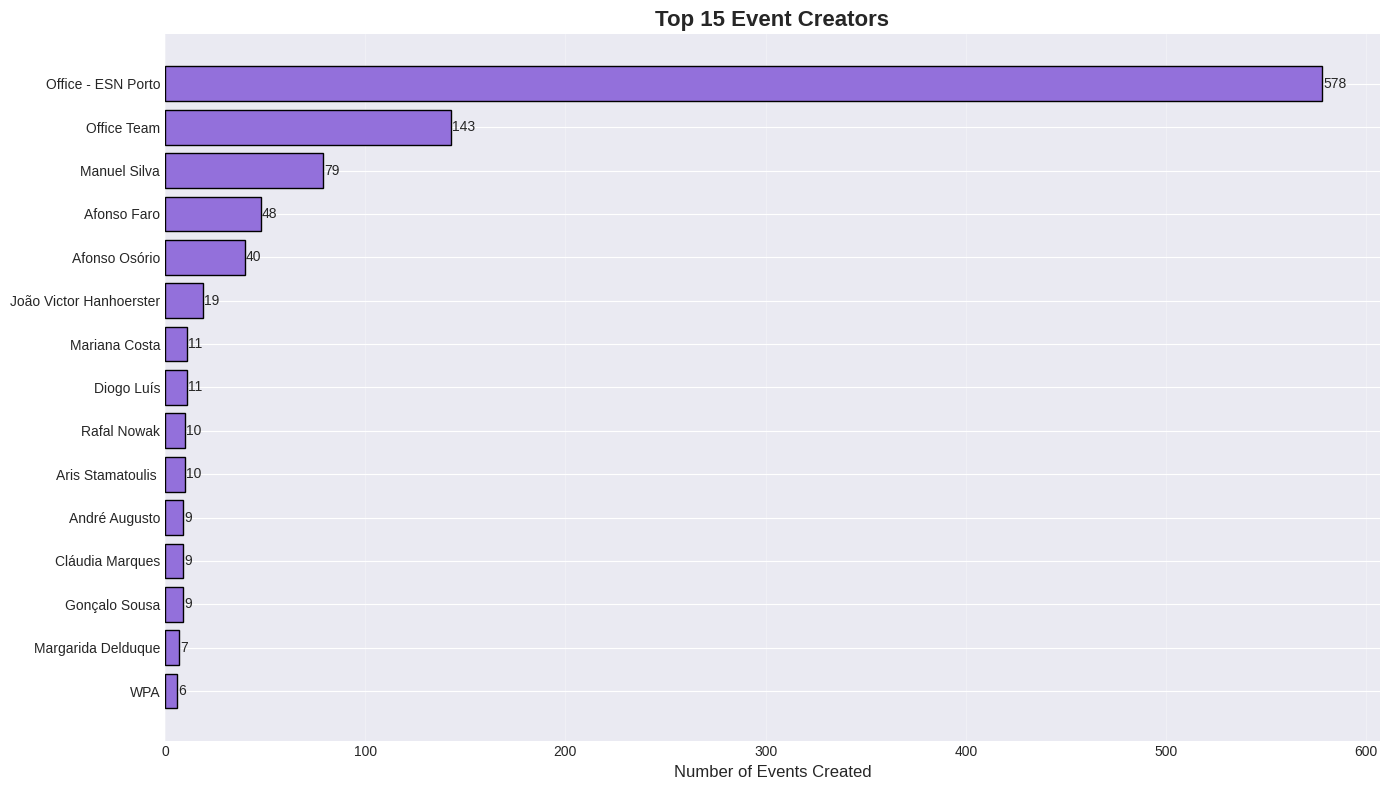


Total unique creators: 48


In [20]:
# Top event creators
top_creators = df_clean['createdBy'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(14, 8))
bars = ax.barh(range(len(top_creators)), top_creators.values, 
               color='mediumpurple', edgecolor='black')
ax.set_yticks(range(len(top_creators)))
ax.set_yticklabels(top_creators.index)
ax.set_xlabel('Number of Events Created', fontsize=12)
ax.set_title('Top 15 Event Creators', fontsize=16, fontweight='bold')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)

# Add value labels
for i, v in enumerate(top_creators.values):
    ax.text(v + 0.5, i, str(v), va='center')

plt.tight_layout()
plt.show()

print(f"\nTotal unique creators: {df_clean['createdBy'].nunique()}")

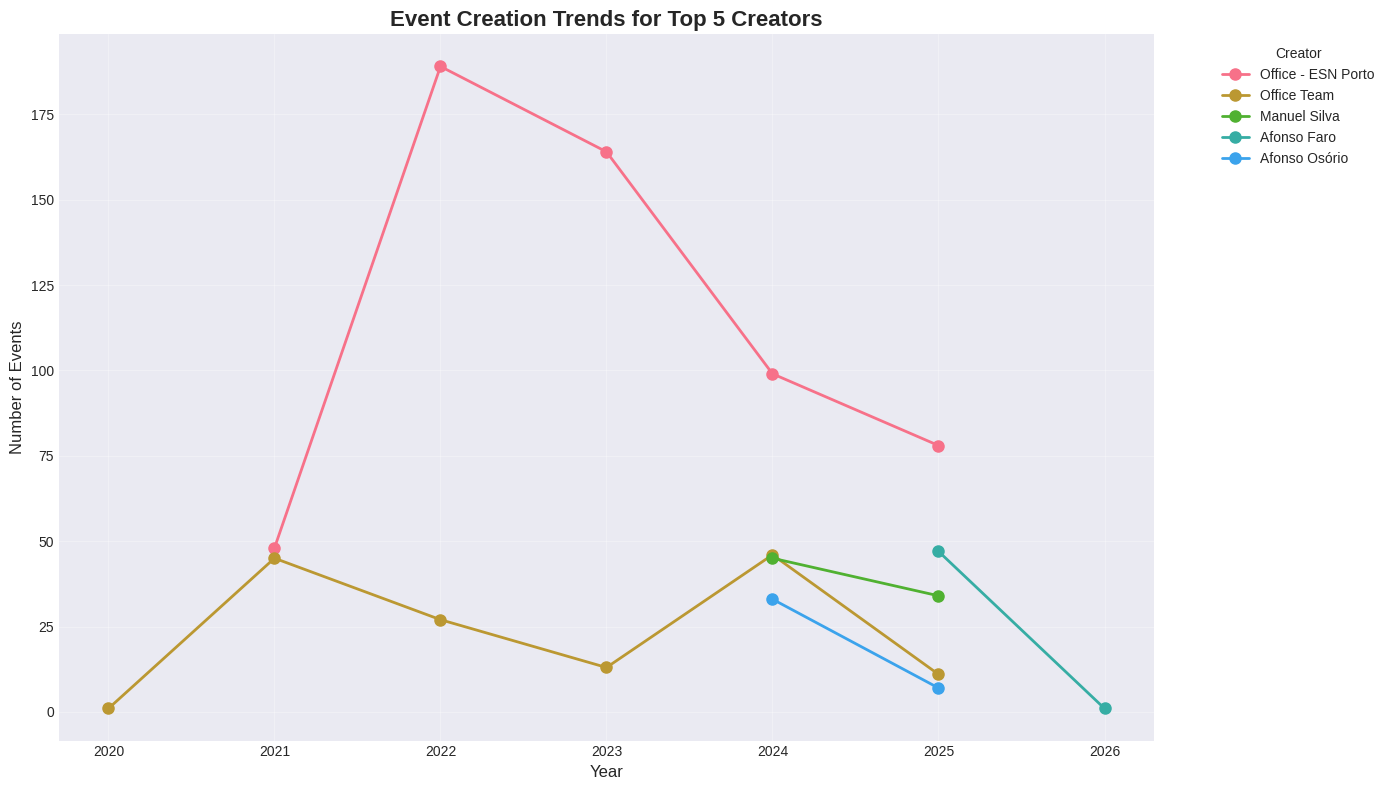

In [21]:
# Creator activity over time
creator_timeline = df_clean.groupby(['year', 'createdBy']).size().reset_index(name='count')
top_5_creators = df_clean['createdBy'].value_counts().head(5).index

fig, ax = plt.subplots(figsize=(14, 8))

for creator in top_5_creators:
    creator_data = creator_timeline[creator_timeline['createdBy'] == creator]
    ax.plot(creator_data['year'], creator_data['count'], 
            marker='o', label=creator, linewidth=2, markersize=8)

ax.set_title('Event Creation Trends for Top 5 Creators', fontsize=16, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Number of Events', fontsize=12)
ax.legend(title='Creator', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 9. ESN Card Analysis

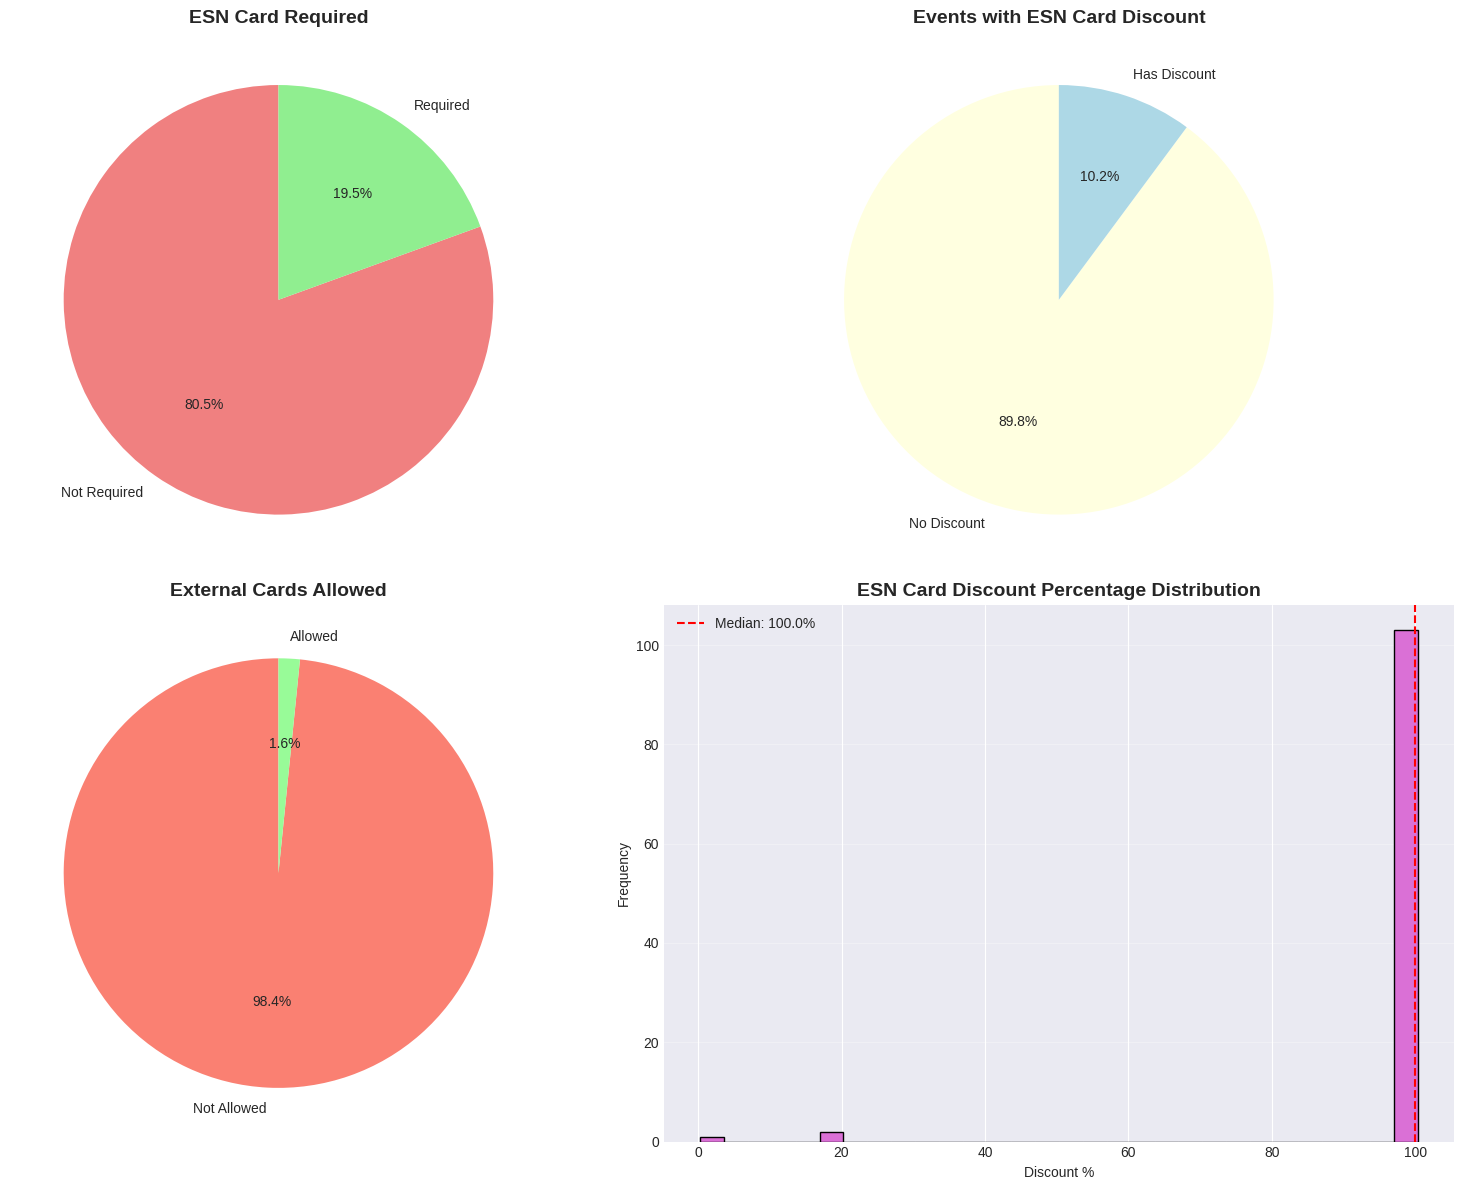

In [22]:
# ESN Card statistics
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# ESN Card Required
esn_required = df_clean['esnCardRequired'].value_counts()
axes[0, 0].pie(esn_required.values, labels=['Not Required', 'Required'], 
               autopct='%1.1f%%', startangle=90, colors=['lightcoral', 'lightgreen'])
axes[0, 0].set_title('ESN Card Required', fontsize=14, fontweight='bold')

# Has ESN Discount
has_discount = df_clean['has_esn_discount'].value_counts()
axes[0, 1].pie(has_discount.values, labels=['No Discount', 'Has Discount'], 
               autopct='%1.1f%%', startangle=90, colors=['lightyellow', 'lightblue'])
axes[0, 1].set_title('Events with ESN Card Discount', fontsize=14, fontweight='bold')

# External Cards Allowed
external_cards = df_clean['allowExternalCards'].value_counts()
axes[1, 0].pie(external_cards.values, labels=['Not Allowed', 'Allowed'], 
               autopct='%1.1f%%', startangle=90, colors=['salmon', 'palegreen'])
axes[1, 0].set_title('External Cards Allowed', fontsize=14, fontweight='bold')

# Discount percentage distribution
df_clean['discount_percentage'] = np.where(
    (df_clean['regularPrice'] > 0) & (df_clean['has_esn_discount']),
    (df_clean['price_discount'] / df_clean['regularPrice'] * 100),
    0
)

discount_pcts = df_clean[df_clean['discount_percentage'] > 0]['discount_percentage']
if len(discount_pcts) > 0:
    axes[1, 1].hist(discount_pcts, bins=30, edgecolor='black', color='orchid')
    axes[1, 1].set_title('ESN Card Discount Percentage Distribution', fontsize=14, fontweight='bold')
    axes[1, 1].set_xlabel('Discount %')
    axes[1, 1].set_ylabel('Frequency')
    axes[1, 1].axvline(discount_pcts.median(), color='red', 
                       linestyle='--', label=f'Median: {discount_pcts.median():.1f}%')
    axes[1, 1].legend()
    axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Event Characteristics

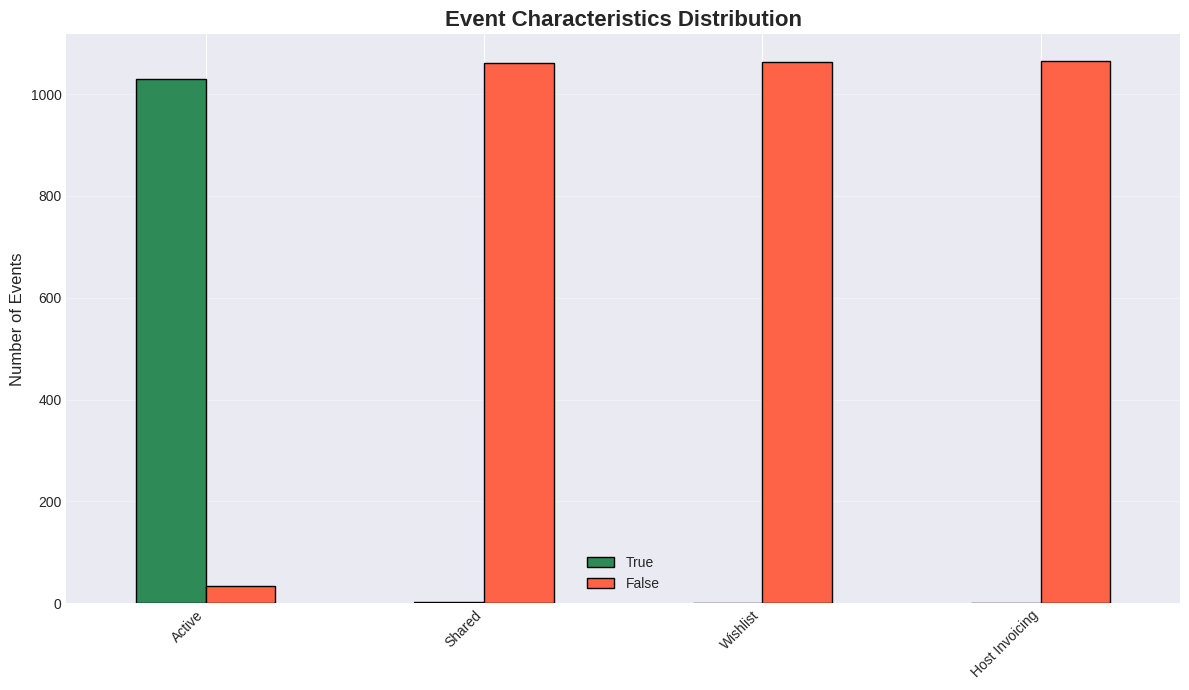

In [23]:
# Event characteristics comparison
characteristics = pd.DataFrame({
    'Active': [df_clean['active'].sum(), (~df_clean['active']).sum()],
    'Shared': [df_clean['shared'].sum(), (~df_clean['shared']).sum()],
    'Wishlist': [df_clean['wishlistEnabled'].sum(), (~df_clean['wishlistEnabled']).sum()],
    'Host Invoicing': [df_clean['hostInvoicing'].sum(), (~df_clean['hostInvoicing']).sum()]
}, index=['True', 'False'])

fig, ax = plt.subplots(figsize=(12, 7))
characteristics.T.plot(kind='bar', ax=ax, color=['seagreen', 'tomato'], edgecolor='black')
ax.set_title('Event Characteristics Distribution', fontsize=16, fontweight='bold')
ax.set_ylabel('Number of Events', fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.legend(['True', 'False'])
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 11. Event Name Analysis

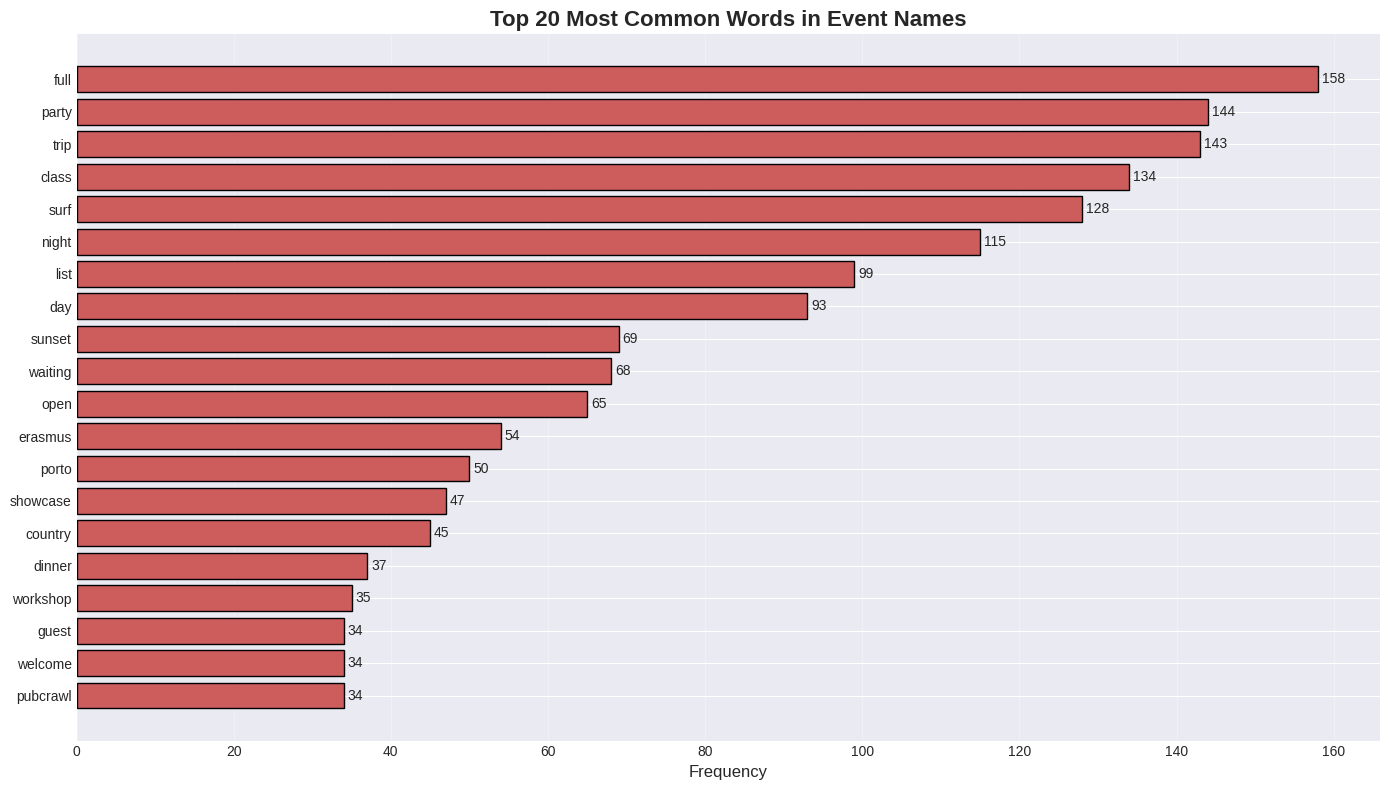

In [24]:
# Most common words in event names
from collections import Counter
import string

# Extract words from event names
all_words = []
stop_words = {'to', 'the', 'a', 'an', 'and', 'or', 'in', 'of', 'at', 'for', 'with', 'by', '-'}

for name in df_clean['name'].dropna():
    # Remove punctuation and convert to lowercase
    words = name.lower().translate(str.maketrans('', '', string.punctuation)).split()
    # Filter out stop words and short words
    words = [w for w in words if w not in stop_words and len(w) > 2]
    all_words.extend(words)

word_freq = Counter(all_words)
top_words = pd.DataFrame(word_freq.most_common(20), columns=['Word', 'Frequency'])

fig, ax = plt.subplots(figsize=(14, 8))
bars = ax.barh(range(len(top_words)), top_words['Frequency'].values, 
               color='indianred', edgecolor='black')
ax.set_yticks(range(len(top_words)))
ax.set_yticklabels(top_words['Word'].values)
ax.set_xlabel('Frequency', fontsize=12)
ax.set_title('Top 20 Most Common Words in Event Names', fontsize=16, fontweight='bold')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)

for i, v in enumerate(top_words['Frequency'].values):
    ax.text(v + 0.5, i, str(v), va='center')

plt.tight_layout()
plt.show()

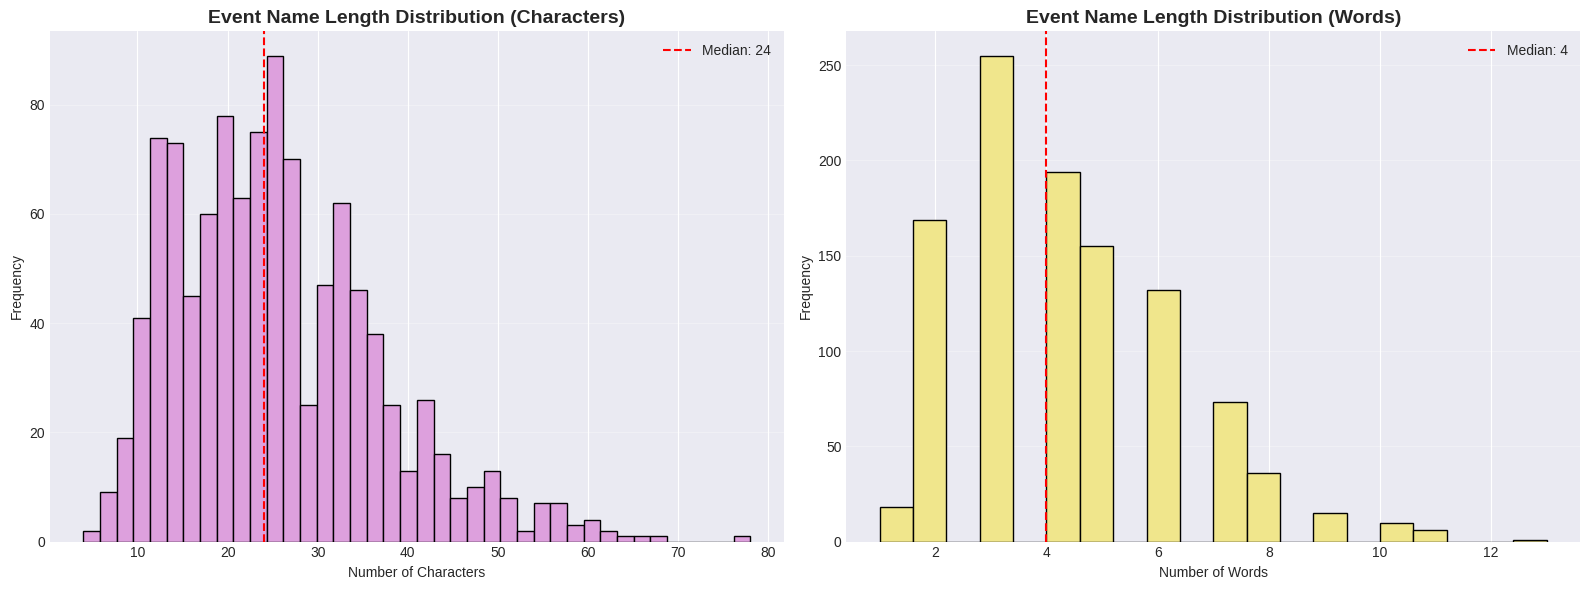

In [25]:
# Event name length analysis
df_clean['name_length'] = df_clean['name'].str.len()
df_clean['name_word_count'] = df_clean['name'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].hist(df_clean['name_length'].dropna(), bins=40, edgecolor='black', color='plum')
axes[0].set_title('Event Name Length Distribution (Characters)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of Characters')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df_clean['name_length'].median(), color='red', 
               linestyle='--', label=f'Median: {df_clean["name_length"].median():.0f}')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

axes[1].hist(df_clean['name_word_count'].dropna(), bins=20, edgecolor='black', color='khaki')
axes[1].set_title('Event Name Length Distribution (Words)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Number of Words')
axes[1].set_ylabel('Frequency')
axes[1].axvline(df_clean['name_word_count'].median(), color='red', 
               linestyle='--', label=f'Median: {df_clean["name_word_count"].median():.0f}')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 12. Correlation Analysis

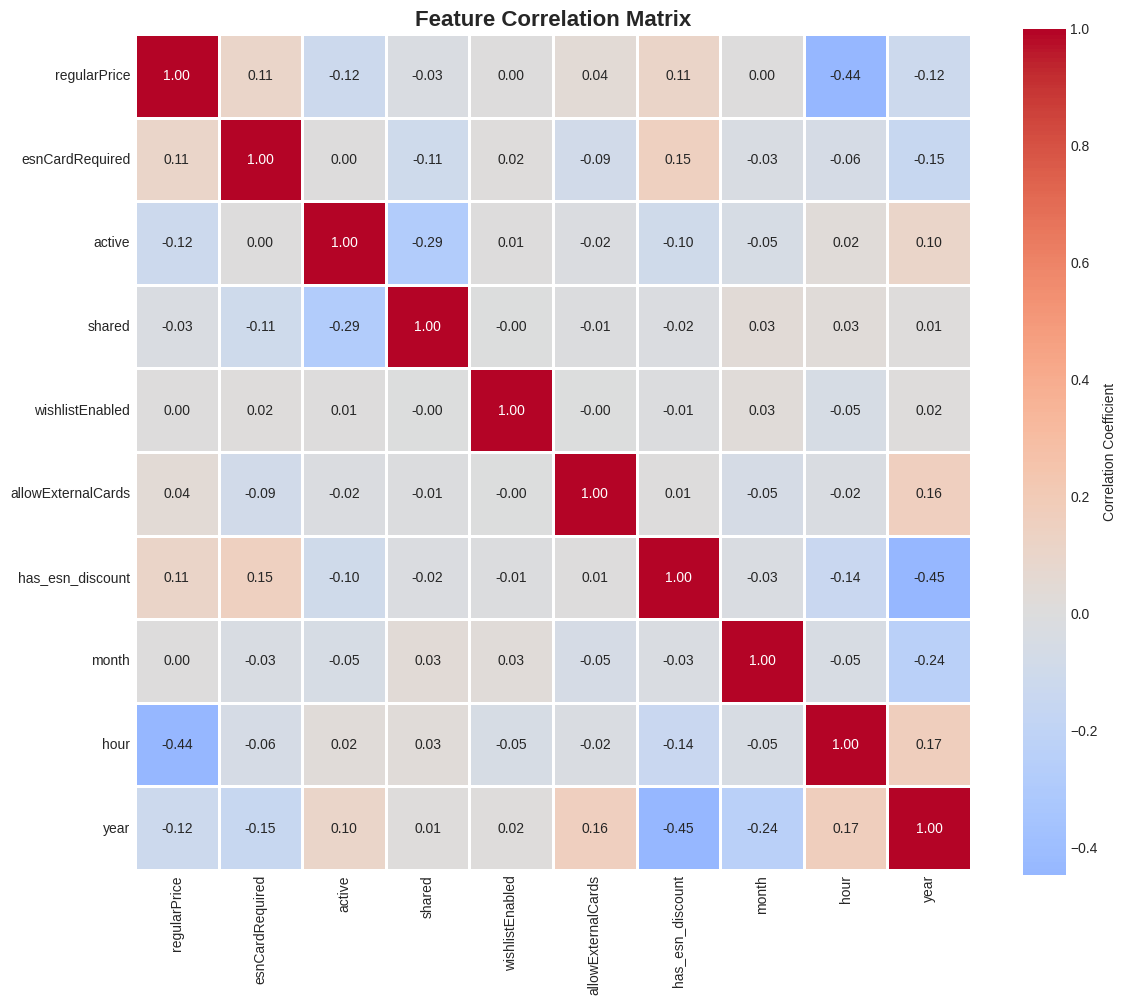

In [26]:
# Create numerical features for correlation
correlation_df = df_clean[[
    'regularPrice', 'esnCardRequired', 'active', 'shared', 
    'wishlistEnabled', 'allowExternalCards', 'has_esn_discount',
    'month', 'hour', 'year'
]].copy()

# Convert boolean to int
for col in ['esnCardRequired', 'active', 'shared', 'wishlistEnabled', 
            'allowExternalCards', 'has_esn_discount']:
    correlation_df[col] = correlation_df[col].astype(int)

# Calculate correlation matrix
corr_matrix = correlation_df.corr()

# Plot correlation heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1,
            cbar_kws={'label': 'Correlation Coefficient'})
plt.title('Feature Correlation Matrix', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 13. Advanced Insights

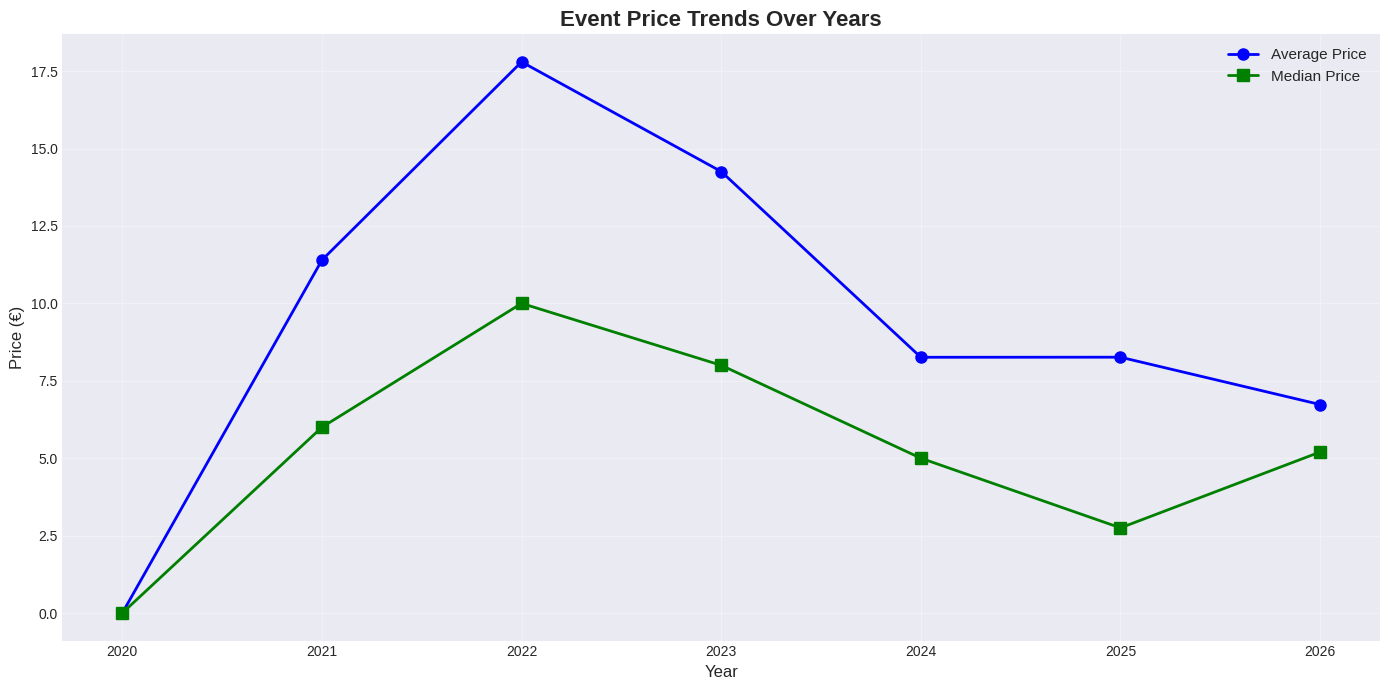

In [27]:
# Price trends over time
price_trends = df_clean.groupby('year')['regularPrice'].agg(['mean', 'median']).reset_index()

fig, ax = plt.subplots(figsize=(14, 7))
ax.plot(price_trends['year'], price_trends['mean'], 
        marker='o', linewidth=2, markersize=8, label='Average Price', color='blue')
ax.plot(price_trends['year'], price_trends['median'], 
        marker='s', linewidth=2, markersize=8, label='Median Price', color='green')
ax.set_title('Event Price Trends Over Years', fontsize=16, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Price (€)', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

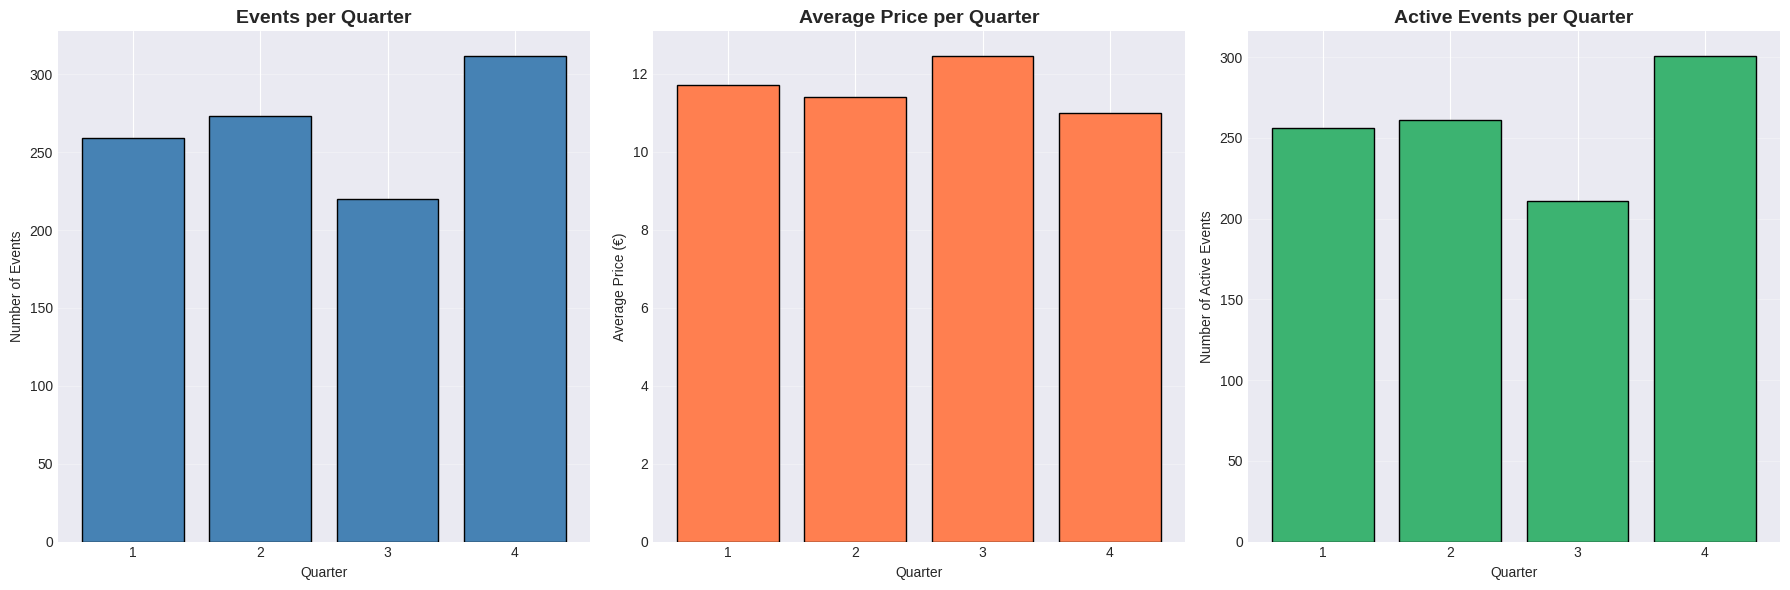


Quarterly Summary:
         Event Count  Avg Price  Active Events
quarter                                       
1                259      11.72            256
2                273      11.42            261
3                220      12.47            211
4                312      11.00            301


In [28]:
# Seasonal patterns (Quarter analysis)
quarter_analysis = df_clean.groupby('quarter').agg({
    'name': 'count',
    'regularPrice': 'mean',
    'active': 'sum'
}).round(2)
quarter_analysis.columns = ['Event Count', 'Avg Price', 'Active Events']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Event count by quarter
axes[0].bar(quarter_analysis.index, quarter_analysis['Event Count'], 
            color='steelblue', edgecolor='black')
axes[0].set_title('Events per Quarter', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Quarter')
axes[0].set_ylabel('Number of Events')
axes[0].set_xticks([1, 2, 3, 4])
axes[0].grid(axis='y', alpha=0.3)

# Average price by quarter
axes[1].bar(quarter_analysis.index, quarter_analysis['Avg Price'], 
            color='coral', edgecolor='black')
axes[1].set_title('Average Price per Quarter', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Quarter')
axes[1].set_ylabel('Average Price (€)')
axes[1].set_xticks([1, 2, 3, 4])
axes[1].grid(axis='y', alpha=0.3)

# Active events by quarter
axes[2].bar(quarter_analysis.index, quarter_analysis['Active Events'], 
            color='mediumseagreen', edgecolor='black')
axes[2].set_title('Active Events per Quarter', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Quarter')
axes[2].set_ylabel('Number of Active Events')
axes[2].set_xticks([1, 2, 3, 4])
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nQuarterly Summary:")
print(quarter_analysis)

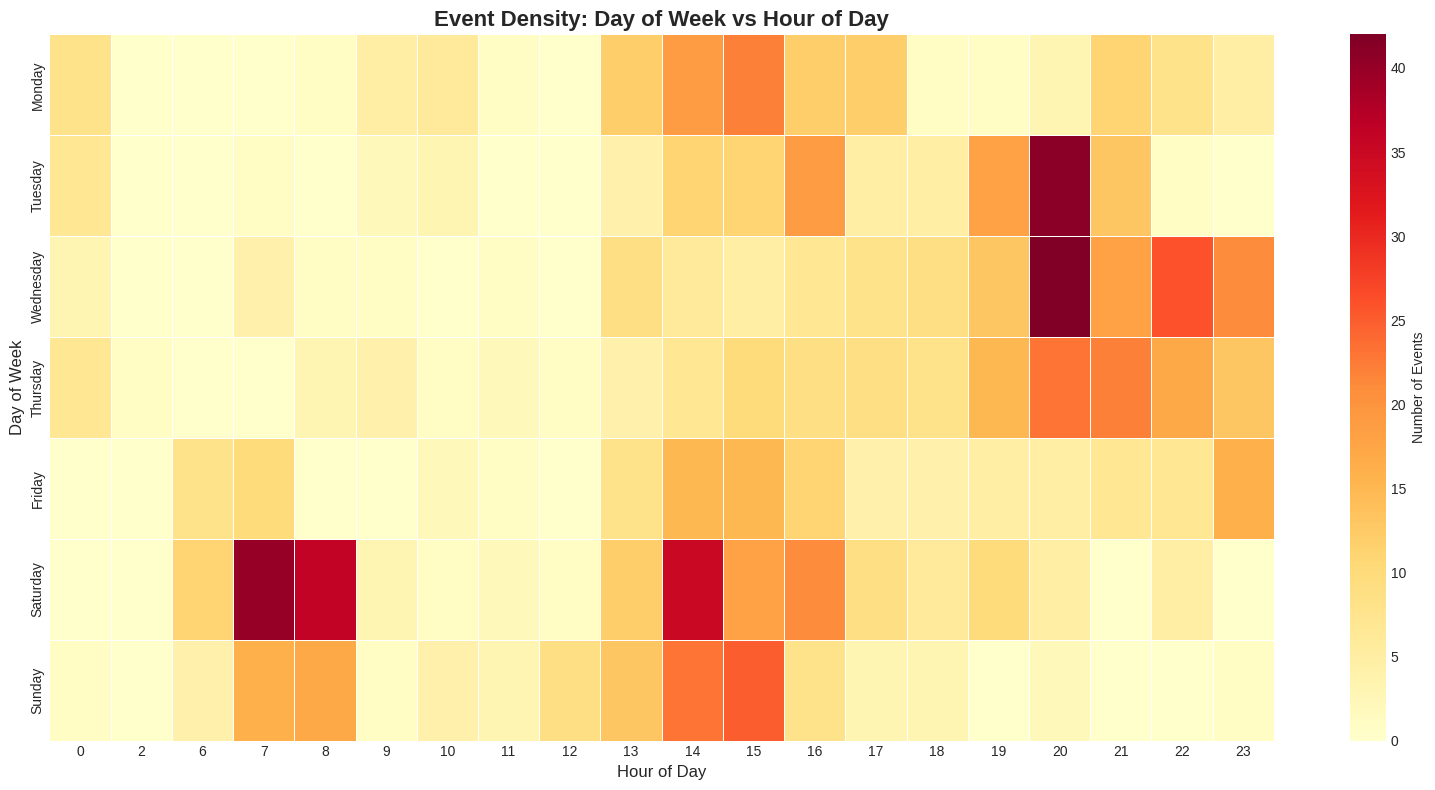

In [29]:
# Event density by day and hour (for events that have occurred)
day_hour_pivot = df_clean.groupby(['day_of_week', 'hour']).size().reset_index(name='count')
day_hour_matrix = day_hour_pivot.pivot(index='day_of_week', columns='hour', values='count').fillna(0)

# Reorder days
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_hour_matrix = day_hour_matrix.reindex(day_order, fill_value=0)

plt.figure(figsize=(16, 8))
sns.heatmap(day_hour_matrix, cmap='YlOrRd', annot=False, fmt='.0f', 
            linewidths=0.5, cbar_kws={'label': 'Number of Events'})
plt.title('Event Density: Day of Week vs Hour of Day', fontsize=16, fontweight='bold')
plt.xlabel('Hour of Day', fontsize=12)
plt.ylabel('Day of Week', fontsize=12)
plt.tight_layout()
plt.show()

## 14. Key Findings Summary

In [30]:
# Generate comprehensive summary
summary = f"""
{'='*80}
ESN PORTO EVENTS - KEY FINDINGS SUMMARY
{'='*80}

DATASET OVERVIEW:
- Total Events: {len(df_clean):,}
- Date Range: {df_clean['datetime'].min().strftime('%Y-%m-%d')} to {df_clean['datetime'].max().strftime('%Y-%m-%d')}
- Unique Locations: {df_clean['location'].nunique()}
- Unique Creators: {df_clean['createdBy'].nunique()}

TEMPORAL PATTERNS:
- Most Active Year: {df_clean['year'].value_counts().idxmax()} ({df_clean['year'].value_counts().max()} events)
- Most Active Month: {df_clean['month_name'].value_counts().idxmax()} ({df_clean['month_name'].value_counts().max()} events)
- Most Active Day: {df_clean['day_of_week'].value_counts().idxmax()} ({df_clean['day_of_week'].value_counts().max()} events)
- Most Common Hour: {df_clean['hour'].value_counts().idxmax()}:00 ({df_clean['hour'].value_counts().max()} events)

PRICING INSIGHTS:
- Average Regular Price: {df_clean['regularPrice'].mean():.2f}€
- Median Regular Price: {df_clean['regularPrice'].median():.2f}€
- Price Range: {df_clean['regularPrice'].min():.2f}€ - {df_clean['regularPrice'].max():.2f}€
- Events with ESN Discount: {df_clean['has_esn_discount'].sum()} ({df_clean['has_esn_discount'].sum()/len(df_clean)*100:.1f}%)
- Average Discount: {df_clean[df_clean['has_esn_discount']]['price_discount'].mean():.2f}€

EVENT CHARACTERISTICS:
- Active Events: {df_clean['active'].sum()} ({df_clean['active'].sum()/len(df_clean)*100:.1f}%)
- Shared Events: {df_clean['shared'].sum()} ({df_clean['shared'].sum()/len(df_clean)*100:.1f}%)
- ESN Card Required: {df_clean['esnCardRequired'].sum()} ({df_clean['esnCardRequired'].sum()/len(df_clean)*100:.1f}%)
- Wishlist Enabled: {df_clean['wishlistEnabled'].sum()} ({df_clean['wishlistEnabled'].sum()/len(df_clean)*100:.1f}%)

TOP PERFORMERS:
- Top Location: {df_clean['location'].value_counts().idxmax()} ({df_clean['location'].value_counts().max()} events)
- Top Creator: {df_clean['createdBy'].value_counts().idxmax()} ({df_clean['createdBy'].value_counts().max()} events)
- Most Common Price Category: {df_clean['price_category'].value_counts().idxmax()}

{'='*80}
"""

print(summary)


ESN PORTO EVENTS - KEY FINDINGS SUMMARY

DATASET OVERVIEW:
- Total Events: 1,064
- Date Range: 2020-10-09 to 2026-12-01
- Unique Locations: 335
- Unique Creators: 48

TEMPORAL PATTERNS:
- Most Active Year: 2024 (303 events)
- Most Active Month: September (220 events)
- Most Active Day: Saturday (215 events)
- Most Common Hour: 20:00 (121 events)

PRICING INSIGHTS:
- Average Regular Price: 11.59€
- Median Regular Price: 5.00€
- Price Range: 0.00€ - 175.00€
- Events with ESN Discount: 108 (10.2%)
- Average Discount: 19.30€

EVENT CHARACTERISTICS:
- Active Events: 1029 (96.7%)
- Shared Events: 3 (0.3%)
- ESN Card Required: 857 (80.5%)
- Wishlist Enabled: 1 (0.1%)

TOP PERFORMERS:
- Top Location: Flower Power Surf School (107 events)
- Top Creator: Office - ESN Porto (578 events)
- Most Common Price Category: Free




## 15. Export Cleaned Data

In [31]:
# Export cleaned data with engineered features
df_clean.to_csv('esn_porto_events_cleaned.csv', index=False, encoding='utf-8')
print("Cleaned data exported to 'esn_porto_events_cleaned.csv'")

# Export summary statistics
with open('esn_porto_summary.txt', 'w', encoding='utf-8') as f:
    f.write(summary)
print("Summary exported to 'esn_porto_summary.txt'")

Cleaned data exported to 'esn_porto_events_cleaned.csv'
Summary exported to 'esn_porto_summary.txt'


## Conclusions

This comprehensive EDA has revealed valuable insights about ESN Porto's event management:

1. **Event Volume & Trends**: Clear temporal patterns in event scheduling and organization
2. **Pricing Strategy**: Well-defined pricing tiers with ESN card benefits for members
3. **Location Distribution**: Concentration of events in specific venues with varying price points
4. **Creator Contributions**: Diverse team with varying levels of event creation activity
5. **Seasonal Patterns**: Quarterly variations in event frequency and characteristics

These insights can inform future event planning, pricing strategies, and resource allocation for ESN Porto.